# **Seccción I: Estracción, Estandarización y Análisis**

# **1. Extracción**

In [111]:
import pandas as pd

In [112]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

In [113]:
# Explorando los datos
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# **2. Estandarización y transformación de datos**

## **2.1 Aplanamiento de datos**

In [114]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [115]:
columnas = ['customer', 'phone', 'internet', 'account']
datos = [df.drop(columns=columnas)]
datos.append(customer)
datos.append(phone)
datos.append(internet)
datos.append(account)

datos = pd.concat(datos, axis=1)
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [116]:
# Explorando los tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## **2.2 Corrección de tipos**

In [117]:
import numpy as np

# Cambiando el tipo de dato de Charges.Total a float64
charges_total = np.where(datos['Charges.Total'].str.strip() == '', np.nan, datos['Charges.Total'])
datos['Charges.Total'] = np.array(charges_total, dtype=np.float64)

In [118]:
# Cambiando los valores de SeniorCitizen a No y Yes, para estandarizar los datos
datos['SeniorCitizen'] = datos['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [119]:
# Verificando los cambios de tipos de datos realizados
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   object 
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [120]:
# Verificando el cambio de valores de SeniorCitizen
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## **2.3 Manejo de valores nulos**

In [121]:
# Verificando si existen valores nulos en Charges.Total
nulos_charges_total = datos['Charges.Total'].isnull().sum()
print(f"Existen {nulos_charges_total} valores nulos en Charges.Total")

Existen 11 valores nulos en Charges.Total


In [122]:
# Reemplazando valores nulos por 0.0 en Charges.Total
datos['Charges.Total'] = datos['Charges.Total'].fillna(0.0)

# Verificando si existen valores nulos en Charges.Total
print(f"Existen {datos['Charges.Total'].isnull().sum()} valores nulos en Charges.Total")

Existen 0 valores nulos en Charges.Total


In [123]:
# Encontrando el número y porcentaje de datos vacios en Churn
conteo_churn = datos['Churn'].value_counts()
print(conteo_churn)

vacios = (datos['Churn'] == '').sum()
print(f"\nValores vacíos: {vacios}")

porcentaje_vacios = (vacios / len(datos)) * 100
print(f"Porecentaje de vacios: {porcentaje_vacios:.2f}%")

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Valores vacíos: 224
Porecentaje de vacios: 3.08%


In [124]:
# Eliminando filas del data frame cuando la columna Churn tiene dato vacios
datos = datos[datos['Churn'] != ''].copy()
datos = datos.reset_index(drop=True)

## **2.4 Estandarizando valores**

In [125]:
# Extrayendo valores unicos de cada columna para analizar los datos
columnas = datos.select_dtypes(include=['object']).columns
for col in columnas:
    print(f"Columna: {col}")
    print(f"Valores: {datos[col].unique()}")
    print("-" * 30)

Columna: customerID
Valores: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------------------------------
Columna: Churn
Valores: ['No' 'Yes']
------------------------------
Columna: gender
Valores: ['Female' 'Male']
------------------------------
Columna: SeniorCitizen
Valores: ['No' 'Yes']
------------------------------
Columna: Partner
Valores: ['Yes' 'No']
------------------------------
Columna: Dependents
Valores: ['Yes' 'No']
------------------------------
Columna: PhoneService
Valores: ['Yes' 'No']
------------------------------
Columna: MultipleLines
Valores: ['No' 'Yes' 'No phone service']
------------------------------
Columna: InternetService
Valores: ['DSL' 'Fiber optic' 'No']
------------------------------
Columna: OnlineSecurity
Valores: ['No' 'Yes' 'No internet service']
------------------------------
Columna: OnlineBackup
Valores: ['Yes' 'No' 'No internet service']
------------------------------
Columna: DeviceProtection
Valores: [

In [126]:
# Estandarizando los valores de las columnas
columnas = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas:
    datos[col] = datos[col].replace({'No internet service': 'No', 'No phone service': 'No'})

In [127]:
# Comprobando valores únicos en columnas
columnas = datos.select_dtypes(include=['object']).columns
for col in columnas:
    print(f"Columna: {col}")
    print(f"Valores: {datos[col].unique()}")
    print("-" * 30)

Columna: customerID
Valores: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------------------------------
Columna: Churn
Valores: ['No' 'Yes']
------------------------------
Columna: gender
Valores: ['Female' 'Male']
------------------------------
Columna: SeniorCitizen
Valores: ['No' 'Yes']
------------------------------
Columna: Partner
Valores: ['Yes' 'No']
------------------------------
Columna: Dependents
Valores: ['Yes' 'No']
------------------------------
Columna: PhoneService
Valores: ['Yes' 'No']
------------------------------
Columna: MultipleLines
Valores: ['No' 'Yes']
------------------------------
Columna: InternetService
Valores: ['DSL' 'Fiber optic' 'No']
------------------------------
Columna: OnlineSecurity
Valores: ['No' 'Yes']
------------------------------
Columna: OnlineBackup
Valores: ['Yes' 'No']
------------------------------
Columna: DeviceProtection
Valores: ['No' 'Yes']
------------------------------
Columna: TechSupport

## **2.5 Mapeo Binario**

In [128]:
# Transformando valores de columnas con dos categorías
columnas = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in columnas:
    datos[col] = datos[col].map({'Yes': 1, 'No': 0})

In [129]:
# Transformando los valores de la columna gender
datos['gender'] = datos['gender'].map({'Male': 1, 'Female': 0})

## **2.6 Dummificación**

In [130]:
# Explotando las columnas de varias categorías
columnas = ['InternetService', 'Contract', 'PaymentMethod']
datos = pd.get_dummies(datos, columns=columnas, drop_first=True, dtype=int)

## **2.6 Estandarización de nombres de variables**

In [131]:
# Estandarizando los nombres de las columnas
datos.columns = [col.replace('.', '_').replace(' ', '_').replace('(', '').replace(')', '') for col in datos.columns]

## **2.7 Eliminación de columnas irrelevantes**

In [132]:
# Eliminación de columnas irrelevantes
datos = datos.drop(columns=['customerID'])

## **2.8 Derivación de Variables**

In [133]:
# Creación de la columna Cuentas_Diarias basándonos en un mes de 30 días
datos['Cuentas_Diarias'] = datos['Charges_Monthly'] / 30

In [134]:
# Creación de la columna Cant_Servicios
servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']

# Creando la columna
servicios_existentes = [s for s in servicios if s in datos.columns]
datos['Cant_Servicios'] = datos[servicios_existentes].sum(axis=1)

In [135]:
# Verificando transformaciones
datos.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,Charges_Total,InternetService_Fiber_optic,InternetService_No,Contract_One_year,Contract_Two_year,PaymentMethod_Credit_card_automatic,PaymentMethod_Electronic_check,PaymentMethod_Mailed_check,Cuentas_Diarias,Cant_Servicios
0,0,0,0,1,1,9,1,0,0,1,...,593.30,0,0,1,0,0,0,1,2.186667,3
1,0,1,0,0,0,9,1,1,0,0,...,542.40,0,0,0,0,0,0,1,1.996667,1
2,1,1,0,0,0,4,1,0,0,0,...,280.85,1,0,0,0,0,1,0,2.463333,1
3,1,1,1,1,0,13,1,0,0,1,...,1237.85,1,0,0,0,0,1,0,3.266667,4
4,1,0,1,1,0,3,1,0,0,0,...,267.40,1,0,0,0,0,0,1,2.796667,2


In [136]:
# Verificando tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Churn                                7043 non-null   int64  
 1   gender                               7043 non-null   int64  
 2   SeniorCitizen                        7043 non-null   int64  
 3   Partner                              7043 non-null   int64  
 4   Dependents                           7043 non-null   int64  
 5   tenure                               7043 non-null   int64  
 6   PhoneService                         7043 non-null   int64  
 7   MultipleLines                        7043 non-null   int64  
 8   OnlineSecurity                       7043 non-null   int64  
 9   OnlineBackup                         7043 non-null   int64  
 10  DeviceProtection                     7043 non-null   int64  
 11  TechSupport                   

# **3. Análisis Exploratorio**

## **3.1 Gráfico de Desbalance de Clases**

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

def grafico_desbalance_clases():
  # Definiendo los colores
  color_map_pastel = {0: '#80DFFF', 1: '#FF9F80'}

  # Calculando los valores absolutos y relativos
  conteo_churn = datos['Churn'].value_counts()
  porcentaje_churn = datos['Churn'].value_counts(normalize=True) * 100

  # 3. Visualización del desbalance
  fig, ax = plt.subplots(figsize=(8, 5))
  sns.countplot(x='Churn', data=datos, ax=ax, hue='Churn', palette=color_map_pastel, legend=False)
  ax.margins(y=0.15)

  # Añadiendo las etiquetas de porcentaje en las barras
  for p, prop in zip(ax.patches, porcentaje_churn):
      ax.annotate(f'{prop:.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', color='black', xytext=(0, 5),
                  textcoords='offset points')

  ax.set_title('Desbalance de Clases: Permanencia vs. Cancelación', pad=15)
  ax.set_xticks(ticks=[0, 1])
  ax.set_xticklabels(['Permanecieron (0)', 'Cancelaron (1)'])
  ax.set_ylabel('Número de Clientes')
  ax.set_xlabel('Estado Cliente')
  sns.despine()

  plt.tight_layout()
  plt.show()

  # Creando tabla resumen
  resumen_churn = pd.DataFrame({
      'Cantidad de Clientes': conteo_churn,
      'Proporción (%)': porcentaje_churn.round(2)
  })
  resumen_churn.index = ['Permanecieron (0)', 'Cancelaron/Churn (1)']

  print("\n\n" + " " * 19 + "\033[1mDISTRIBUCIÓN DE CLASES\033[0m" + "\n")
  display(resumen_churn)

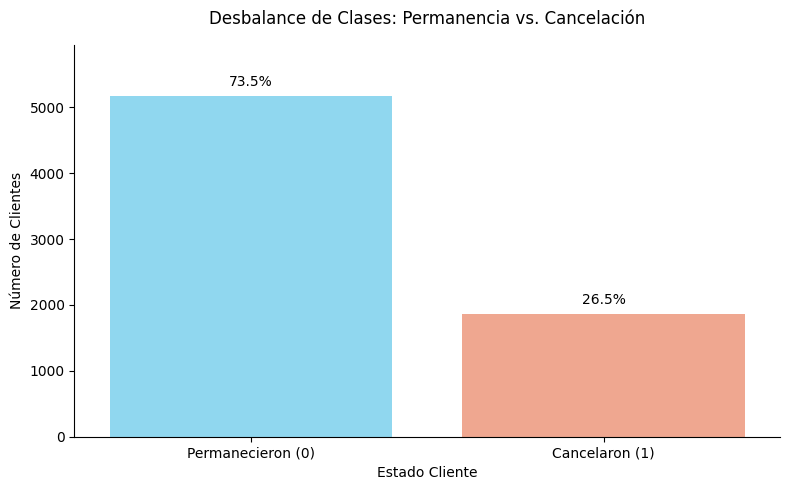



                   DISTRIBUCIÓN DE CLASES



,Cantidad de Clientes,Proporción (%)
Permanecieron (0),5174,73.46
Cancelaron/Churn (1),1869,26.54


In [138]:
grafico_desbalance_clases()

**ANÁLISIS**

* El 73.5% de los clientes permanecen activos en la empresa, mientras que un 26.5% han decidido cancelar sus servicios.
* Estamos frente a un caso de desbalance de clases, una proporción aproximada de 3 a 1 a favor de la clase mayoritaria.

## **3.2 Mapa de Calor de Correlación**

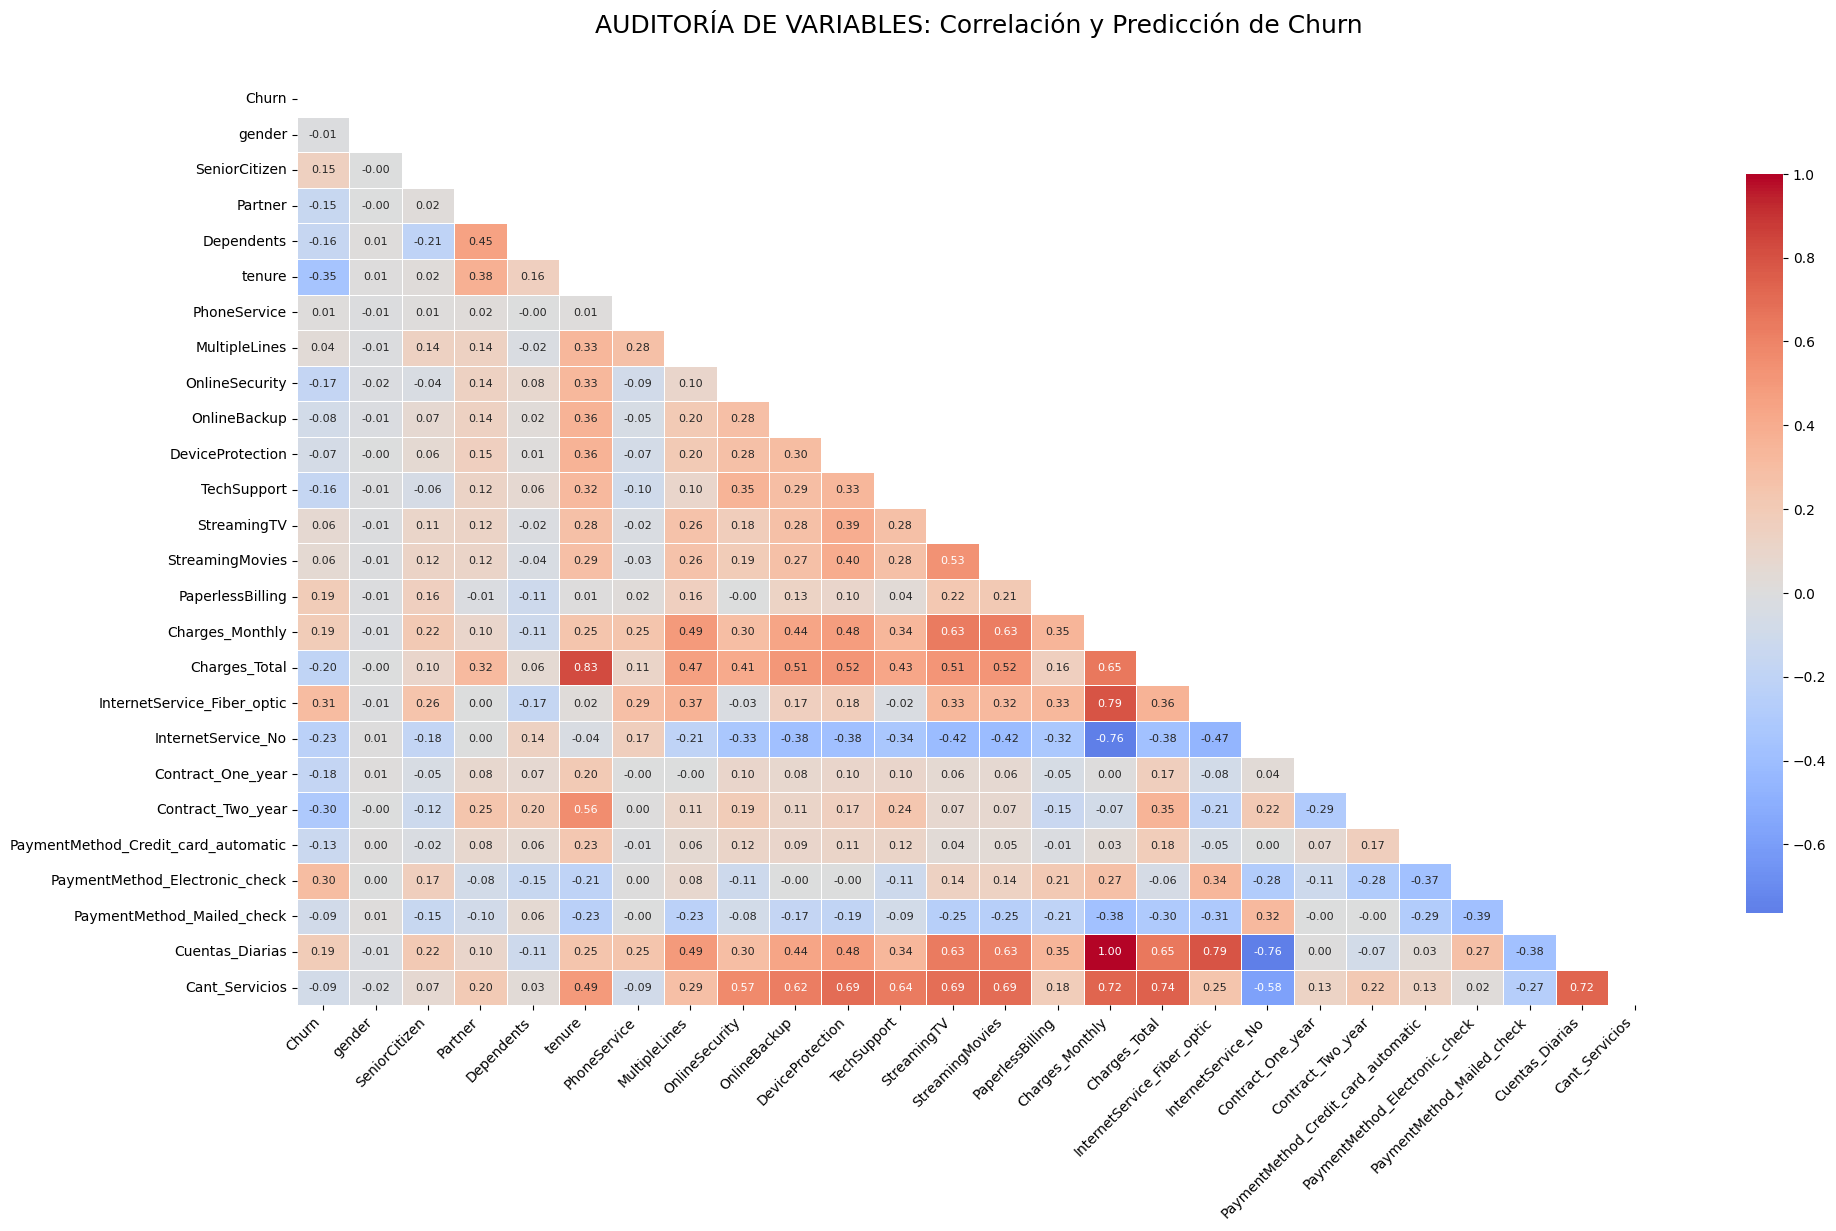

In [139]:
import numpy as np

# 1. Cálculando la Matriz de Pearson
corr_matrix = datos.corr()

# 2. Configurando el lienzo
plt.figure(figsize=(22, 12))

# 3. Ocultando la mitad superior (información duplicada)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dibujando el Mapa de Calor
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=.5,
            annot_kws={"size": 8},
            cbar_kws={"shrink": .8})

plt.title('AUDITORÍA DE VARIABLES: Correlación y Predicción de Churn',
          fontsize=18, pad=35)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
sns.despine(left=True, bottom=True)
plt.show()

**ANÁLISIS**

<ul>
  <li>Las variables InternetService_Fiber_optic (0.31) y PaymentMethod_Electronic_check (0.30), tienen las correlaciones positivas más altas con la fuga de clientes.</li>
  <li>Charges_Monthly (0.19) y PaperlessBilling (0.19) tienen una correlación positiva moderada-baja, mostrando que facturas mensuales más altas tienden a alinearse con mayores tasas de cancelación.</li>
  <li>Las variables tenure (-0.35) y Contract_Two_year (-0.30), representan las anclas más fuertes del negocio. A mayor antigüedad y contratos más largos, la probabilidad de fuga disminuye drásticamente.</li>
  <li>El mapa de calor también nos revela fuertes dependencias entre las propias características (Multicolinealidad):</li>
  <ul>
    <li>Tenure y Charges_Total (0.83), tienen una correlación casi perfecta, a más meses en la empresa, mayor es el gasto acumulado.</li>
    <li>Cuentas_Diarias y Charges_Monthly (1.00), tienen una correlación perfecta de 1. Lo que indica que Cuentas_Diarias es simplemente una derivación matemática lineal de los cargos mensuales.</li>
    <li>Cant_Servicios y Charges_Monthly (0.72), una fuerte relación, más servicios implican una factura más cara.</li>
  </ul>
</ul>

In [140]:
# PREDICTORES DE CANCELACIÓN
print("\n" + " " * 9 + "\033[1mTOP 3 PREDICTORES DE CANCELACIÓN\033[0m")

churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

print(f"\n\033[1mRiesgo (+) :\033[0m Aumentan la probabilidad de Churn")
print(churn_corr[1:4].to_string())

print(f"\n\033[1mLealtad (-) :\033[0m Protegen al cliente de la cancelación")
print(churn_corr.tail(3).sort_values(ascending=True).to_string())


         TOP 3 PREDICTORES DE CANCELACIÓN

Riesgo (+) : Aumentan la probabilidad de Churn
InternetService_Fiber_optic       0.308020
PaymentMethod_Electronic_check    0.301919
Charges_Monthly                   0.193356

Lealtad (-) : Protegen al cliente de la cancelación
tenure               -0.352229
Contract_Two_year    -0.302253
InternetService_No   -0.227890


In [141]:
# MULTICOLINEALIDAD
print("\n\n" + " " * 8 + "\033[1mALERTA DE REDUNDANCIA (MULTICOLINEALIDAD)\033[0m")

# Buscamos pares con correlación > 0.90 (Variables que dicen lo mismo)
redundancia = corr_matrix.unstack()
redundancia = redundancia[abs(redundancia) > 0.90].drop_duplicates()
redundancia = redundancia[redundancia < 1.0]

if not redundancia.empty:
    print("Se detectaron variables altamente redundantes (>0.90):")
    display(redundancia)
    print("\n\033[1mNota:\033[0m Considera eliminar una de cada par antes de entrenar.")
else:
    print("¡Felicidades! No hay variables con redundancia crítica.")



        ALERTA DE REDUNDANCIA (MULTICOLINEALIDAD)
Se detectaron variables altamente redundantes (>0.90):


,,0
Charges_Monthly,Cuentas_Diarias,1.0



Nota: Considera eliminar una de cada par antes de entrenar.


In [142]:
# Eliminando la variable redundante Cuentas_Diarias
datos = datos.drop(columns=['Cuentas_Diarias'])

## **3.3 Gráfico de Cajas**

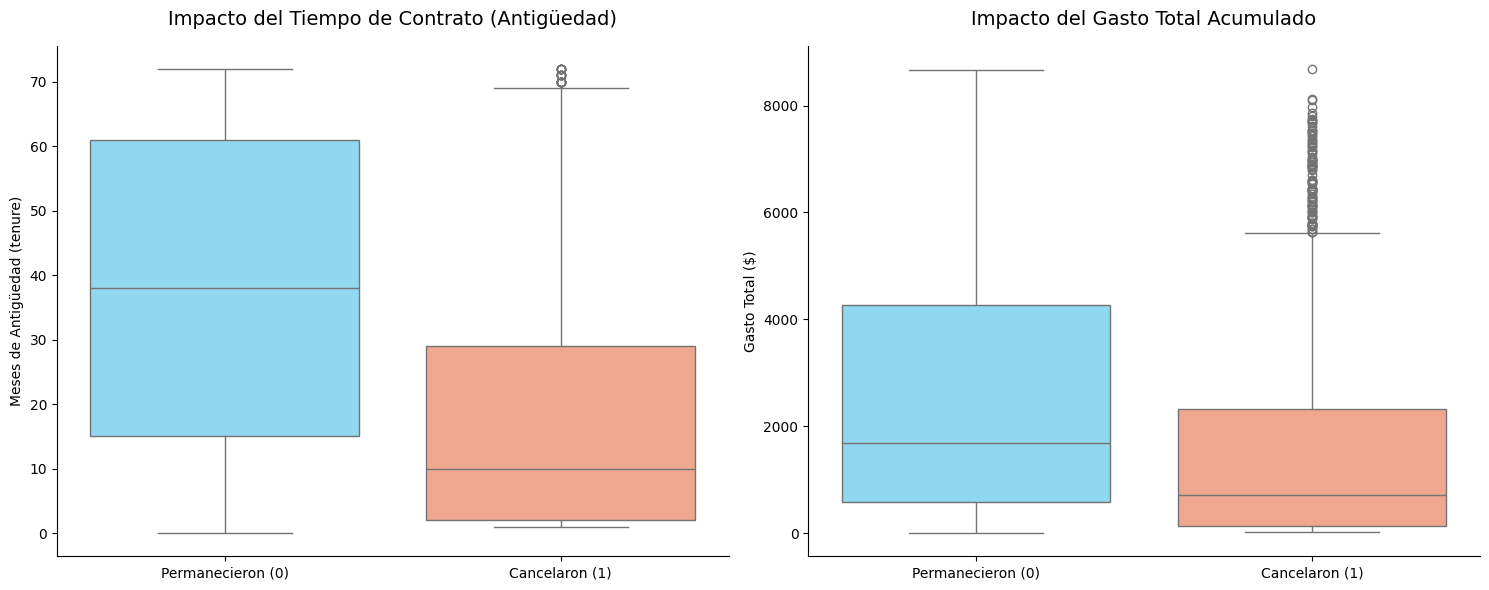

In [143]:
# Definiendo los colores
color_map_pastel = {0: '#80DFFF', 1: '#FF9F80'}

# Configurando el lienzo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Tiempo de Contrato (tenure) vs Cancelación
sns.boxplot(x='Churn', y='tenure', data=datos, ax=axes[0], palette=color_map_pastel, hue='Churn', legend=False)
axes[0].set_title('Impacto del Tiempo de Contrato (Antigüedad)', fontsize=14, pad=15)
axes[0].set_xticks([0, 1],['Permanecieron (0)', 'Cancelaron (1)'])
axes[0].set_ylabel('Meses de Antigüedad (tenure)')
axes[0].set_xlabel('')

# Gráfico 2: Gasto Total (Charges_Total) vs Cancelación
sns.boxplot(x='Churn', y='Charges_Total', data=datos, ax=axes[1], palette=color_map_pastel, hue='Churn', legend=False)
axes[1].set_title('Impacto del Gasto Total Acumulado', fontsize=14, pad=15)
axes[1].set_xticks([0, 1],['Permanecieron (0)', 'Cancelaron (1)'])
axes[1].set_ylabel('Gasto Total ($)')
axes[1].set_xlabel('')

sns.despine()
plt.tight_layout()
plt.show()

**ANALISIS**

**Impacto del Tiempo de Contrato (Antigüedad):**

*  El cliente leal tiene una mediana de 38 meses, el que cancela tiene una mediana de apenas 10 meses.
*  El riesgo no es constante. Existe un ***período de prueba*** crítico. Si logramos que el cliente supere los primeros 30 meses, la probabilidad de que ***se quede*** aumenta drásticamente.
*  Los outliers que aparecen sobre los 70 meses son clientes *leales* que se fueron tras casi 6 años. Son pocos, pero son los que más duelen al negocio.

**Impacto del Gasto Total Acumulado:**

*  Existe una gran cantidad de puntos negros (outliers) en la barra de Cancelaron (1).
*  Hay una masa crítica de clientes que, a pesar de haber gastado entre 6,000  y 8,000 (mucho más que el cliente promedio que se queda), decidieron marcharse.
*  El precio no es el único factor, estos clientes de alto valor son *clientes pesados* y su salida afecta el flujo de caja mucho más que 10 clientes básicos.

# **4. Arquitectura del Modelo**

## **4.1 Separación de Datos: entrenamiento y prueba**

In [144]:
from sklearn.model_selection import train_test_split
# 1. Definiendo variables: X: Todas las características (predictores)
                         # y: Nuestra variable objetivo (Churn)
X = datos.drop(columns=['Churn'])
y = datos['Churn']

# 2. Realizando la división
# 80% para entrenamiento y 20% para pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. RESUMEN DE LA PARTICIÓN
print("\n" + " " * 8 + "\033[1mRESUMEN DE LA PARTICIÓN\033[0m") #" " * 8
print(f"Muestras totales: {len(datos)}")
print(f"Set de Entrenamiento (X_train): {X_train.shape[0]} muestras")
print(f"Set de Prueba (X_test): {X_test.shape[0]} muestras")

print("\n" + "\033[1mVERIFICACIÓN DE ESTRATIFICACIÓN (Churn %)\033[0m")
print(f"Proporción en Entrenamiento: {y_train.value_counts(normalize=True)[1]:.2%}")
print(f"Proporción en Pruebas:      {y_test.value_counts(normalize=True)[1]:.2%}")


        RESUMEN DE LA PARTICIÓN
Muestras totales: 7043
Set de Entrenamiento (X_train): 5634 muestras
Set de Prueba (X_test): 1409 muestras

VERIFICACIÓN DE ESTRATIFICACIÓN (Churn %)
Proporción en Entrenamiento: 26.54%
Proporción en Pruebas:      26.54%


## **4.2 Escalado de Características**

In [145]:
from sklearn.preprocessing import StandardScaler

# Escalando variables
columnas_a_escalar = ['tenure', 'Charges_Monthly', 'Charges_Total', 'Cant_Servicios']

# 1. Instanciando el escalador
scaler = StandardScaler()

# 2. Entrenando el escalador con X_train
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ajustamos (fit) y transformamos (transform) el set de entrenamiento
X_train_scaled[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])

# SOLO transformamos (transform) el set de prueba usando las reglas aprendidas arriba
X_test_scaled[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])

# 4. Verificación visual del éxito del escalado
print("\n" + " " * 14 + "\033[1mVERIFICACIÓN DE ESCALADO (X_train)\033[0m")
display(X_train_scaled[columnas_a_escalar].head())

print("\n\033[1mEstadísticas de 'Charges_Total' escalado")
print(f"Media: {X_train_scaled['Charges_Total'].mean():.4f}")
print(f"Desviación Estándar: {X_train_scaled['Charges_Total'].std():.4f}")


              VERIFICACIÓN DE ESCALADO (X_train)


,tenure,Charges_Monthly,Charges_Total,Cant_Servicios
3793,1.124891,0.968250,1.398565,0.518023
3192,-0.827880,-1.521717,-0.913119,-1.113055
4922,-1.234707,0.513560,-0.946146,-0.025670
3926,0.026457,0.323690,0.071090,1.061715
3859,-0.746514,0.698434,-0.495126,-0.025670



Estadísticas de 'Charges_Total' escalado
Media: -0.0000
Desviación Estándar: 1.0001


**JUSTIFICACIÓN**

* Las variables tenure, Charges_Monthly, Charges_Total y Cant_Servicios fueron escaladas porque si introducimos variables con magnitudes dispares (tenure oscilaba entre 0 y 72 meses, Charges_Total alcanzaba los $8,000), el modelo sufriría un sesgo de magnitud y creerá erróneamente que el gasto total es cientos de veces más importante que la antigüedad, simplemente porque su valor numérico es más grande. Al estandarizar los datos, ponemos a todas las variables en un mismo nivel. Esto asegura que los coeficientes calculados por la Regresión Logística reflejen el verdadero peso predictivo de la variable, permitiendo que el algoritmo converja más rápido y entregue resultados confiables, sin dejarse engañar por el tamaño bruto de los números.
* La aplicación de la estandarización es un paso obligatorio e indispensable para garantizar la validez estadística del modelo de Regresión Logística, evitando sesgos de magnitud. Aunque este paso es innecesario para el modelo Random Forest, aplicarlo uniformemente asegurará un entorno de experimentación controlado donde ambos algoritmos competirán bajo las mismas condiciones de entrada.

## **4.3 Sobremuestreo de la Clase Minoritaria**

In [146]:
from imblearn.over_sampling import SMOTE

# BALANCEANDO CLASES
print("\n" + " " * 6 + "\033[1mANTES DE SMOTE\033[0m")
print(y_train.value_counts())

# 1. Instanciamos SMOTE
# Usamos random_state=42 para que los clientes sintéticos sean siempre los mismos
smote = SMOTE(random_state=42)

# 2. Entrenamos y aplicamos SMOTE SOLO en el set de entrenamiento escalado
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 3. Verificamos el resultado
print("\n\n" + " " * 4 + "\033[1mDESPUÉS DE SMOTE\033[0m")
print(y_train_smote.value_counts())

print(f"\n{len(X_train_smote)} muestras balanceadas")

# Verificación de seguridad: El set de prueba no debe haber cambiado
print(f"\n(Verificación: El set de prueba tiene {len(X_test)} muestras reales)")


      ANTES DE SMOTE
Churn
0    4139
1    1495
Name: count, dtype: int64


    DESPUÉS DE SMOTE
Churn
0    4139
1    4139
Name: count, dtype: int64

8278 muestras balanceadas

(Verificación: El set de prueba tiene 1409 muestras reales)


# **5. Entrenamiento y Evaluación de Modelos**

## **5.1 Regresión Logística**

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


# 1. Instanciando el modelo
modelo_logreg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenando el modelo con los datos balanceados
modelo_logreg.fit(X_train_smote, y_train_smote)

# 3. Realizando la predicción sobre el set de prueba
y_pred_logreg = modelo_logreg.predict(X_test_scaled)

def reporte_clasificacion_regresion_logistica():
  # 4. Evaluando los resultados
  print("\n" + " " * 12 + "\033[1mREPORTE DE CLASIFICACIÓN: Regresión Logística\033[0m\n")
  print(classification_report(y_test, y_pred_logreg))

In [148]:
reporte_clasificacion_regresion_logistica()


            REPORTE DE CLASIFICACIÓN: Regresión Logística

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



**ANALISIS**

* De los 374 clientes que realmente se iban a ir de la empresa, el modelo logró detectar el 76% de ellos.
* De todos los clientes a los que el modelo predijo ***que se van a ir***, solo el 54% realmente lo hizo. El otro 46% son clientes leales que el modelo confundió.
* El modelo tiene un 90% de certeze en predecir que un cliente se quedará.

### **5.1.1 Matriz de Confusión**

In [149]:
# Visualizando la Matriz de Confusión
def matriz_confusion_regresion_logistica():
  cm_logreg = confusion_matrix(y_test, y_pred_logreg)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Predicción: Se Quedan (0)', 'Predicción: Cancelan (1)'],
              yticklabels=['Real: Se Quedan (0)', 'Real: Cancelan (1)'],
              cbar=False, annot_kws={"size": 14, "weight": "bold"})

  plt.title('Matriz de Confusión: Regresión Logística', fontsize=16, pad=25)
  plt.ylabel('Realidad (Lo que pasó)', fontsize=12)
  plt.xlabel('Predicción (Lo que dijo el modelo)', fontsize=12)
  sns.despine(left=True, bottom=True)
  plt.show()

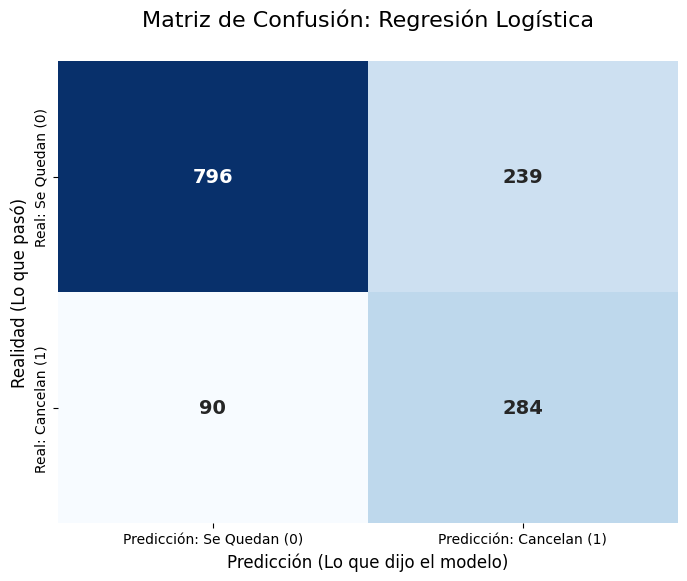

In [150]:
matriz_confusion_regresion_logistica()

**ANALISIS**

*  Hay 284 clientes que estanaban a punto de irse y el modelo los detectó (vedaderos positivos).
*  Hay 90 clientes que el modelo dijo que se quedarían pero se fueron (falsos negativos).
*  Hay 239 clientes leales que que el modelo marcó en riezgo de fuga (falsos positivos).
*  El modelo identificó a 796 clientes leales (vedaderos negativos).

### **5.1.2 Gráfico de Pesos Predictivos**

In [151]:
# 1. Extrayendo los coeficientes matemáticos que el modelo aprendió
coeficientes = modelo_logreg.coef_[0]

# 2. Emparejando con el nombre de sus columnas
importancia_df = pd.DataFrame({
    'Variable': X_train_smote.columns,
    'Peso_Logistico': coeficientes
})

# 3. Ordenando desde el mayor riesgo de fuga hasta la mayor lealtad
importancia_df = importancia_df.sort_values(by='Peso_Logistico', ascending=False)

def grafico_pesos_predictivos_regresion_logistica():
  # 4. Graficando los resultados
  plt.figure(figsize=(12, 10))

  colores = ['#FF9F80' if x > 0 else '#80DFFF' for x in importancia_df['Peso_Logistico']]
  sns.barplot(x='Peso_Logistico', y='Variable', data=importancia_df, palette=colores, hue='Variable', legend=False)
  plt.title('\nAnálisis de Pesos Predictivos: Factores Determinantes en la Tasa de Cancelación (Churn)\n', fontsize=16, pad=20)
  plt.xlabel('Impacto en la Decisión (Pesos Positivos = Fuga | Pesos Negativos = Retención)', fontsize=12)
  plt.ylabel('Variables', fontsize=12)
  plt.axvline(x=0, color='grey', linestyle='--', linewidth=1.5)
  sns.despine(left=True, bottom=True)
  plt.tight_layout()
  plt.show()

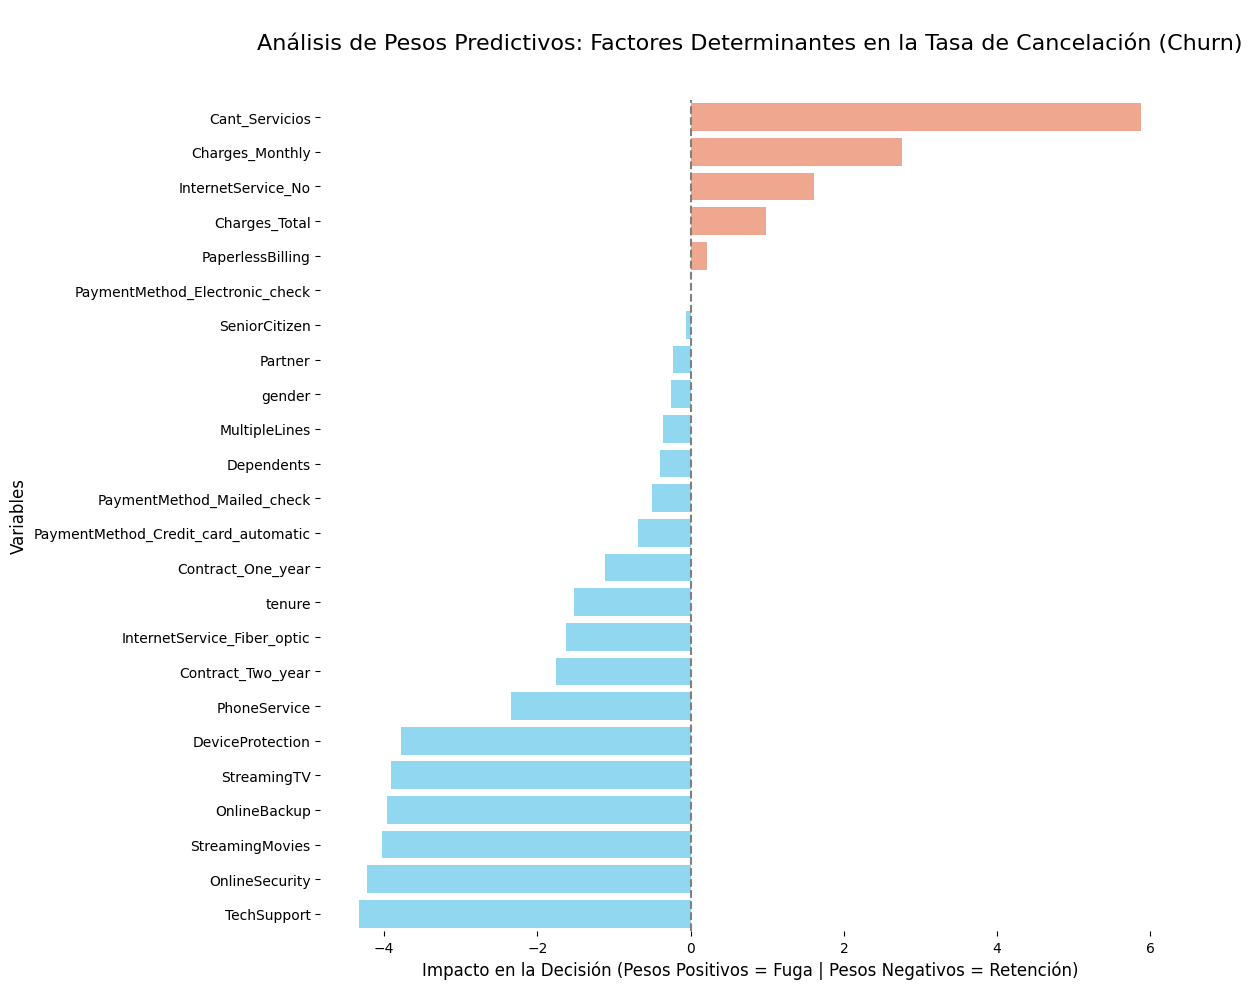

In [152]:
grafico_pesos_predictivos_regresion_logistica()

**ANÁLISIS**

* A medida que un cliente acumula un mayor número total de servicios, su probabilidad de cancelar es mayor.
* Las facturas altas ahuyentan a los clientes.
* Tener estos servicios individuales reduce fuertemente la probabilidad de fuga.
* Tener individualmente los servicios: TechSupport, OnlineSecurity, StreamingMovies y OnlineBackup reduce fuertemente la probabilidad de fuga.
* El contrato a dos años (Contract_Two_year) y la antigüedad (tenure) son fuertes escudos protectores.

**DIAGNÓSTICO**

Cuando un cliente contrata un servicio de valor agregado que realmente aprecia (como Soporte Técnico o Seguridad), se vuelve leal; sin embargo, si la empresa  le empaqueta o le vende demasiados servicios adicionales llega un punto de quiebre donde el cliente siente que paga demasiado por cosas que quizás ni usa, y decide cancelar todo de golpe por el costo de la facturación mensual.

**RECOMENDACIÓNES**

* Dejar de vender servicios adicionales solo para subir la facturación.
* Enfócarse en vender los servicios correctos (Soporte Técnico, Seguridad).
* Ofrecer contratos a largo plazo.

## **5.2 Random Forest**

In [153]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instanciando el modelo de Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Entrenando el modelo con los datos balanceados
modelo_rf.fit(X_train_smote, y_train_smote)

# 3. Realizando la predicción sobre el set de prueba
y_pred_rf = modelo_rf.predict(X_test_scaled)

def reporte_clasificacion_Random_Forest():
  # 4. Evaluando los resultados
  print("\n" + " " * 12 + "\033[1mREPORTE DE CLASIFICACIÓN: Random Forest\n\033[0m")
  print(classification_report(y_test, y_pred_rf))

In [154]:
reporte_clasificacion_Random_Forest()


            REPORTE DE CLASIFICACIÓN: Random Forest

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1035
           1       0.55      0.61      0.58       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.77      0.77      1409



**ANÁLISIS**

* Random Forest solo logró detectar al 61% de los clientes que se van a ir.
* Dejó escapar a muchísimos más clientes que la Regresión Logística.
* Este modelo tiene un acierto del 55% en predecir que un cliente se irá.
* Este modelo es bueno prediciendo a los clientes que se quedarán con un 82% de acierto.

### **5.2.1 Matriz de Confusión**

In [155]:
# Visualizando la Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

def matriz_confusión_Random_Forest():
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
              xticklabels=['Predicción: Se Quedan (0)', 'Predicción: Cancelan (1)'],
              yticklabels=['Real: Se Quedan (0)', 'Real: Cancelan (1)'],
              cbar=False, annot_kws={"size": 14, "weight": "bold"})

  plt.title('\nMatriz de Confusión: Random Forest', fontsize=16, pad=25)
  plt.ylabel('Realidad (Lo que pasó)', fontsize=12)
  plt.xlabel('Predicción (Lo que dijo el modelo)', fontsize=12)
  sns.despine(left=True, bottom=True)
  plt.show()

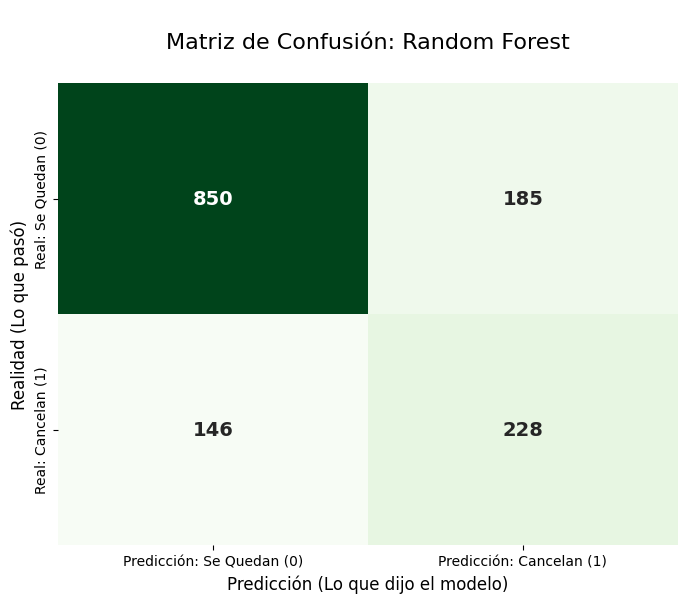

In [156]:
matriz_confusión_Random_Forest()

**ANÁLISIS**

* De todos los clientes que iban a cancelar su servicio Random Forest detecto solo a 228 (verdaderos positivos). Lo que significa que no detecto a 56 clientes que la Regresión Logística si detectó.
* El modelo predijo que 146 clientes se quedarían pero realmente se fueron (falsos negativos). Nuevamente el margen de error de la Regresión Logística es menor, 90 frente a 146.
* Random Forest predijo que 185 clientes que realmente se quedaron, se irian (falsos positivos). Aquí este modelo es más óptimo que la Regresión Logística.
* Este modelo identificó correctamente a 850 cliente que realmnete se quedaron, superando a la Regresión Logística.

### **3.2.2 Gráfico de Importancia de Características**

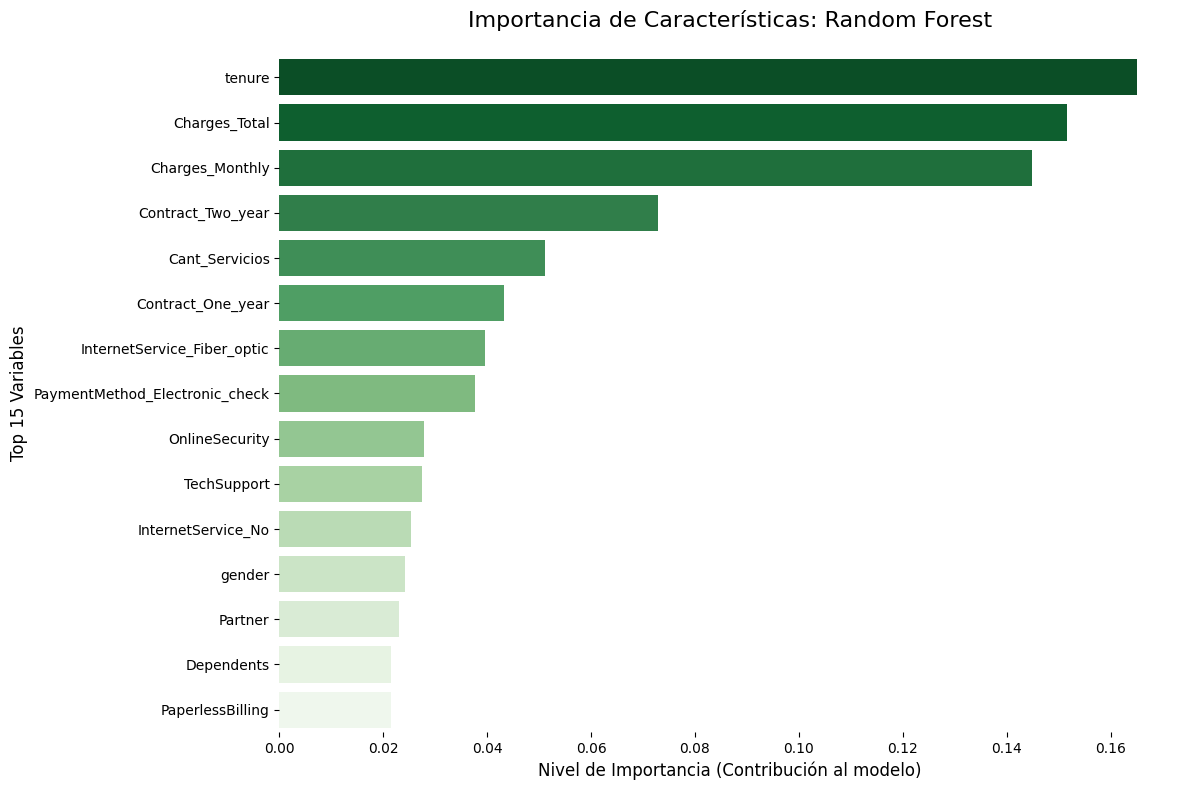

In [157]:
importancias_rf = modelo_rf.feature_importances_

# 1. Creando un DataFrame emparejando la variable con su puntuación
importancia_rf_df = pd.DataFrame({
    'Variable': X_train_smote.columns,
    'Importancia': importancias_rf
})

# 2. Ordenando de mayor a menor y tomando las top 15
importancia_rf_df = importancia_rf_df.sort_values(by='Importancia', ascending=False).head(15)

# 3. Graficando
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=importancia_rf_df,
            palette='Greens_r', hue='Variable', legend=False)
plt.title('Importancia de Características: Random Forest', fontsize=16, pad=20)
plt.xlabel('Nivel de Importancia (Contribución al modelo)', fontsize=12)
plt.ylabel('Top 15 Variables', fontsize=12)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**ANÁLISIS**

* Las tres variables que determinan la decisión del modelo son: tenure (Antigüedad), Charges_Total (Gasto Total) y Charges_Monthly (Cargos Mensuales). Lo que confirma que el tiempo que el cliente permanece y su sensibilidad al precio son los predictores más fuertes para prever una fuga.
* Contract_Two_year y Contract_One_year aparecen en la parte superior del ranking. Lo que confirma los hallazgos de la Regresión Logística: el tipo de contrato que firma el cliente es un factor crítico y la falta de un contrato a largo plazo facilita la barrera de salida.
* Cant_Servicios, ocupa el quinto lugar demostrando que la acumulación de servicios en la cuenta de un cliente aporta información de alto valor predictivo para detectar su salida por el costo que paga.

# **5. Informe de Análisis Predictivo y Estrategias de Mitigación de Fuga de Clientes (Churn)**

### **1. Resumen Ejecutivo**

El presente informe detalla los resultados del análisis de la implementación de un modelo diseñado para anticipar la cancelación de servicios por parte de los clientes.

El análisis inicial reveló una tasa de fuga del 26.5% frente a un 73.5% de retención, lo que representa un riesgo financiero.

A través del preprocesamiento de datos, estandarización matemática, balanceo de clases y la evaluación de algoritmos, se ha identificado qué clientes tienen mayor probabilidad de abandonar la empresa y los factores que impulsan esa decisión.

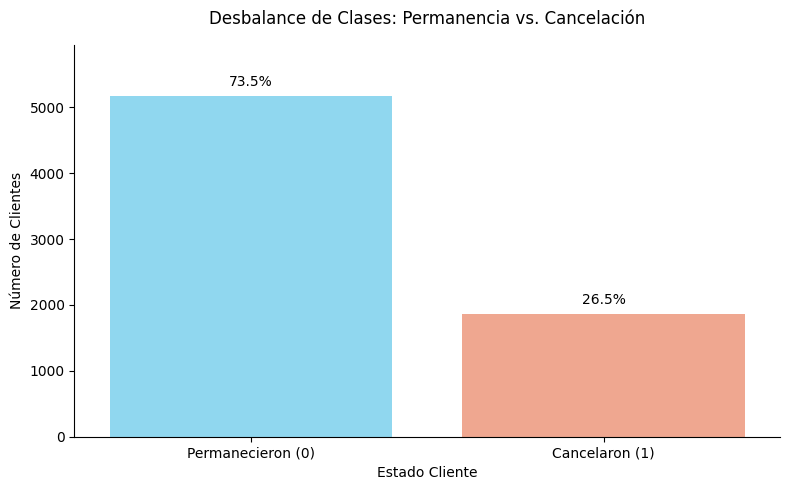



                   DISTRIBUCIÓN DE CLASES



,Cantidad de Clientes,Proporción (%)
Permanecieron (0),5174,73.46
Cancelaron/Churn (1),1869,26.54


In [158]:
grafico_desbalance_clases()

### **2. Evaluación Técnica y Selección del Modelo**

Se desarrollaron y contrastaron dos arquitecturas de modelado: Regresión Logística y Random Forest.

**A. Regresión Logística**

Es el ***modelo ganador*** por su alta capacidad para minimizar los Falsos Negativos. Logró un Recall del 76% en la clase minoritaria, lo que significa que detecta exitosamente a casi 8 de cada 10 clientes antes de que cancelen. Prioriza la seguridad de la cartera al ser altamente sensible a las señales de fuga.

In [159]:
reporte_clasificacion_regresion_logistica()


            REPORTE DE CLASIFICACIÓN: Regresión Logística

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



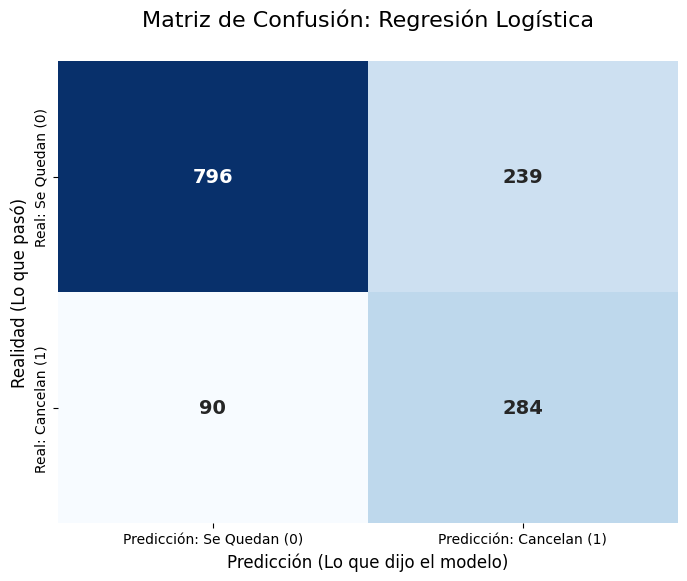

In [160]:
matriz_confusion_regresion_logistica()

**B. Random Forest**

Modelo Descartado, presentó problemas de generalización (overfitting sobre la clase balanceada), tuvo un Recall de solo el 61%. Permitió que una cantidad inaceptable de deserciones reales pasaran desapercibidas.

In [161]:
reporte_clasificacion_Random_Forest()


            REPORTE DE CLASIFICACIÓN: Random Forest

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1035
           1       0.55      0.61      0.58       374

    accuracy                           0.77      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.77      0.77      1409



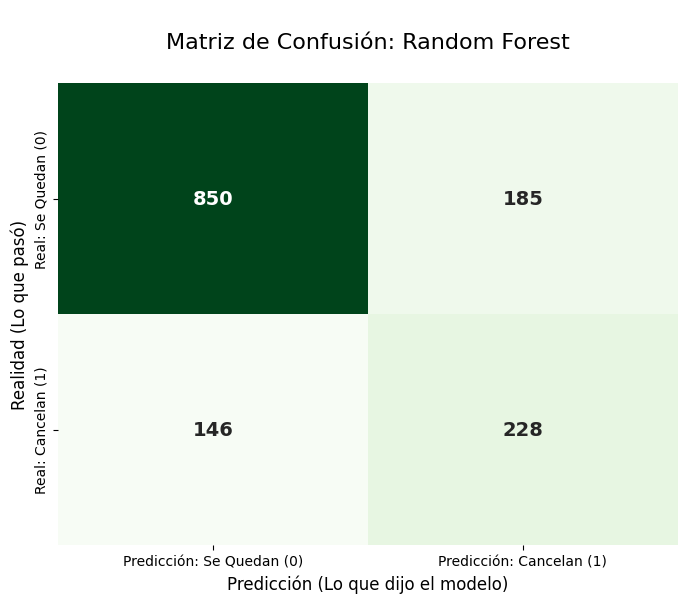

In [162]:
matriz_confusión_Random_Forest()

### **3. Principales Factores que Influyen en la Cancelación**

El análisis de los coeficientes del modelo lineal y la reducción de impureza del modelo de ensamble revelaron tres motores principales de deserción:

* La variable de ingeniería Cant_Servicios y métricas directas como Charges_Monthly mostraron un alto valor predictivo hacia la cancelación. La acumulación de servicios incrementa la factura mensual, la cual posee una correlación directa del 0.72 con la cantidad de servicios contratados. Existe un punto de quiebre donde la percepción de valor del cliente colapsa frente al costo total, provocando la cancelación de su paquete.

* Los contratos mensuales (Month-to-month) reducen la barrera de salida a cero, siendo un catalizador primario de fuga. Por el contrario, variables como tenure (antigüedad) y Contract_Two_year (contrato a dos años) son los escudos de retención más fuertes del modelo.

* Servicios de valor agregado operativo, específicamente TechSupport (Soporte Técnico) y OnlineSecurity (Seguridad en Línea), demostraron tener un peso fuertemente negativo hacia la cancelación en ambos algoritmos. Sin ellos el cliente acelera la decisión de abandono.

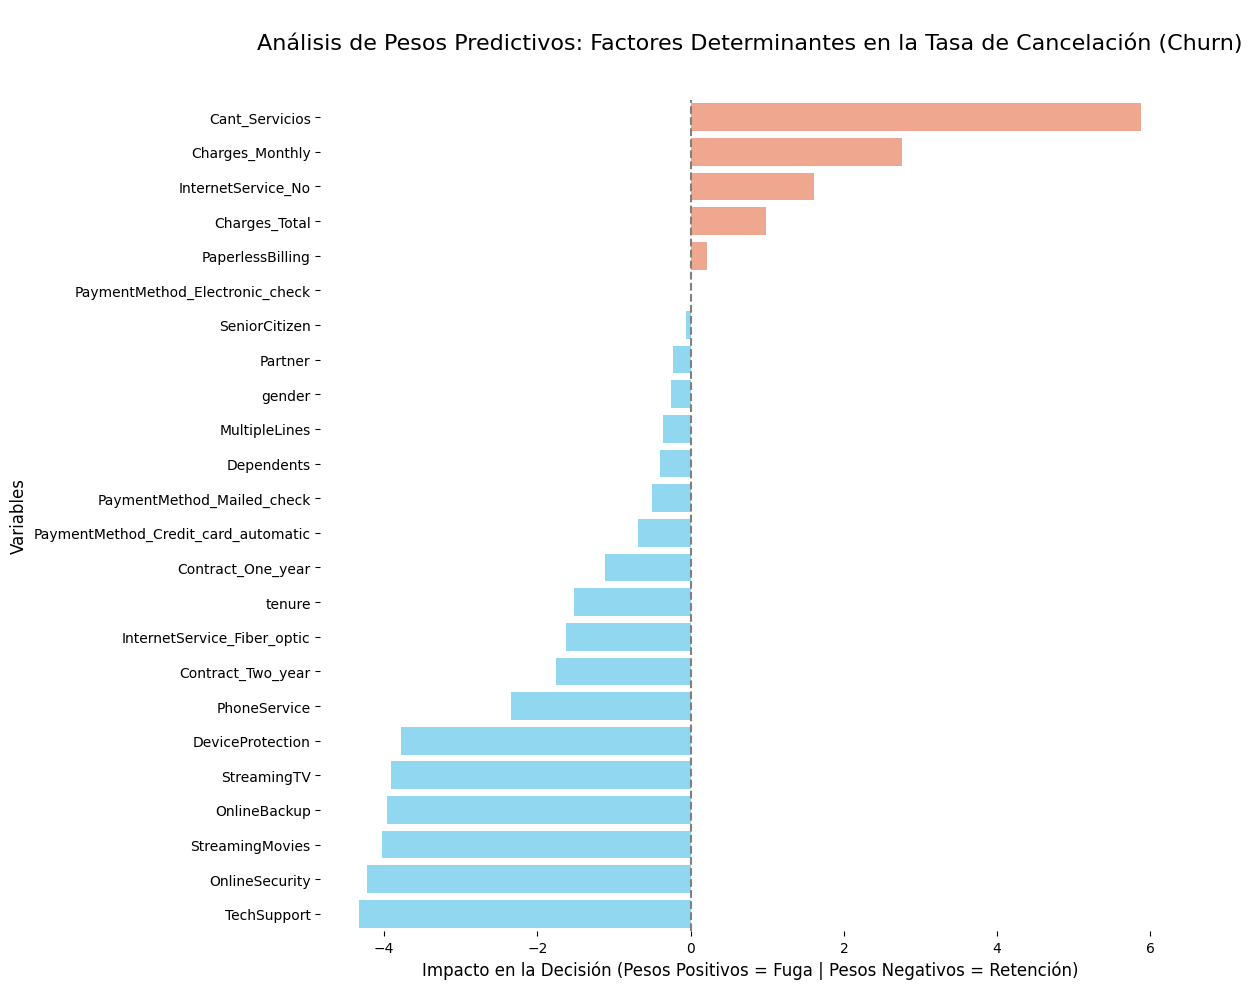

In [163]:
grafico_pesos_predictivos_regresion_logistica()

### **4. Propuestas de Estrategias de Retención**

<ol>
  <li><strong>Migración del Modelo de Venta:</strong> Limitar las campañas que buscan añadir servicios innecesarios únicamente para elevar el ticket promedio. Se debe perfilar al cliente y ofrecer únicamente los servicios que realmente consumirá, optimizando la relación costo-beneficio percibida.</li>
  <li><strong>Campañas de Transición hacia Contratos a Largo Plazo:</strong> Diseñar incentivos financieros (ej. descuentos en los primeros 3 meses o equipos sin costo) dirigidos exclusivamente al segmento de clientes que actualmente poseen contratos mensuales, con el objetivo de convertirlos a modalidades de uno o dos años, estabilizando así los ingresos.</li>
  <li><strong>Democratizar los Servicios de Anclaje:</strong> Evaluar la viabilidad financiera de incluir TechSupport o un nivel básico de OnlineSecurity de forma gratuita o a un costo marginal dentro de los paquetes base. El modelo demuestra que estos servicios generan una fricción positiva que fideliza al usuario.</li>
  <li><strong>Intervención Preventiva:</strong> Desplegar el modelo de Regresión Logística en producción para que califique diariamente a la base de clientes. El departamento de retención deberá enfocar sus esfuerzos de contacto proactivo únicamente en el decil superior de clientes marcados con alta probabilidad de fuga.</li>
</ol>